In [1]:
# Libraries & Imports
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

print('All libraries loaded.')

All libraries loaded.


### Preprocessing and Feature Engineering
**Goal of this notebook:** turn the cleaned 10-city Open-Meteo dataset into a model-ready feature matrix, building directly on the hand-off from `01_data_collection_and_eda.ipynb`.

This notebook aims to answer the following questions:
1. Can the 10 city datasets be merged into a single tidy frame without losing the per-city identity needed for geographic encoding?
2. Do the ~15 predictors identified in the EDA hold up under a redundancy check (correlation matrix + VIF), or does that check change the selection?
3. Which lag, rolling, pressure-tendency, circular-wind and calendar features add forecast skill without leaking future information?
4. How is the time-aware train / validation / test split from the EDA implemented, and how are scalers fit without touching validation or test data?
5. In what format should the resulting datasets be persisted for the modelling notebooks?

#### Recap from notebook 01
- The dataset is complete: no missing values, no date gaps, all values within physical bounds (2016-01-01 to 2026-05-01, 10 cities, 33 raw columns).
- 15 key variables were identified by correlation with `tavg`: `tavg, tmax, tmin, prcp, rain, snow, pres, cloud, rh, dewpt, vpd_max, soil_moist, soil_temp, wspd, wgust_max`.
- `wdir` carries information but needs a sin/cos decomposition before use (Pearson r is meaningless for a circular variable).
- Multicollinearity was flagged within the pressure, humidity, cloud and wind groups (r > 0.85-0.97) - confirmed candidates for a VIF check.
- Geographic diversity (`elev`, `coastal`, `lat`, `lon`) is real and should be encoded explicitly for a multi-city model.
- The test split was revised to: train 2016-2023, validation 2024, primary test 2025 (calendar year), recency test Jan-May 2026.

#### Constants
Re-using the same paths, city files, metadata and column-rename map as `01_data_collection_and_eda.ipynb` so the merged frame is built in exactly the same way. The processed, model-ready datasets are written to `../data/processed/`.

The train / validation / test boundaries below are the ones derived from the KS-test analysis in notebook 01 (seasonally-balanced calendar-year test set,2026 kept as a separate recency check).

In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../reports/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Filename - short city key used everywhere in code
CITY_FILES = {
    'sofia': 'open-meteo-sofia-2016-2026-42.71N23.40E555m.csv',
    'varna': 'open-meteo-varna-2016-2026-43.20N27.94E68m.csv',
    'veliko_tarnovo': 'open-meteo-tarnovo-2016-2026-43.13N25.62E226m.csv',
    'ruse': 'open-meteo-ruse-2016-2026-43.83N26.01E36m.csv',
    'kardzhali': 'open-meteo-kurdzhali-2016-2026-41.65N25.36E248m.csv',
    'pleven': 'open-meteo-pleven-2016-2026-43.41N24.56E96m.csv',
    'burgas': 'open-meteo-burgas-2016-2026-42.57N27.44E32m.csv',
    'haskovo': 'open-meteo-haskovo-2016-2026-41.93N25.51E195m.csv',
    'vidin': 'open-meteo-vidin-2016-2026-43.97N22.94E43m.csv',
    'yundola': 'open-meteo-yundola-2016-2026-42.00N23.84E1213m.csv',
}

CITY_METADATA = {
    'sofia': {'lat': 42.7065, 'lon': 23.3973, 'elev': 555, 'climate_zone': 'continental_plain'},
    'varna': {'lat': 43.2167, 'lon': 27.9167, 'elev': 68, 'climate_zone': 'coastal_maritime'},
    'veliko_tarnovo': {'lat': 43.1300, 'lon': 25.6200, 'elev': 226, 'climate_zone': 'subcontinental'},
    'ruse': {'lat': 43.8300, 'lon': 26.0100, 'elev': 36, 'climate_zone': 'danube_valley'},
    'kardzhali': {'lat': 41.6500, 'lon': 25.3600, 'elev': 248, 'climate_zone': 'continental_plain'},
    'pleven': {'lat': 43.4100, 'lon': 24.5600, 'elev': 96, 'climate_zone': 'continental_plain'},
    'burgas': {'lat': 42.5659, 'lon': 27.4374, 'elev': 32, 'climate_zone': 'coastal_maritime'},
    'haskovo': {'lat': 41.9300, 'lon': 25.5100, 'elev': 195, 'climate_zone': 'continental_plain'},
    'vidin': {'lat': 43.9700, 'lon': 22.9400, 'elev': 43, 'climate_zone': 'danube_valley'},
    'yundola': {'lat': 42.0035, 'lon': 23.8428, 'elev': 1213, 'climate_zone': 'alpine'},
}

# Raw Open-Meteo header short name. Encoding artefacts in the raw headers (°C shown as В°C) are handled by reading with encoding='utf-8' and matching on the normalised name.
COLUMN_RENAME = {
    'temperature_2m_mean (°C)': 'tavg',
    'temperature_2m_max (°C)': 'tmax',
    'temperature_2m_min (°C)': 'tmin',
    'precipitation_sum (mm)': 'prcp',
    'rain_sum (mm)': 'rain',
    'snowfall_sum (cm)': 'snow',
    'snowfall_water_equivalent_sum (mm)': 'snow_weq',
    'wind_speed_10m_max (km/h)': 'wspd_max',
    'wind_speed_10m_mean (km/h)': 'wspd',
    'wind_speed_10m_min (km/h)': 'wspd_min',
    'wind_gusts_10m_max (km/h)': 'wgust_max',
    'wind_gusts_10m_mean (km/h)': 'wgust',
    'wind_gusts_10m_min (km/h)': 'wgust_min',
    'wind_direction_10m_dominant (°)': 'wdir',
    'cloud_cover_max (%)': 'cloud_max',
    'cloud_cover_min (%)': 'cloud_min',
    'cloud_cover_mean (%)': 'cloud',
    'relative_humidity_2m_max (%)': 'rh_max',
    'relative_humidity_2m_min (%)': 'rh_min',
    'relative_humidity_2m_mean (%)': 'rh',
    'dew_point_2m_max (°C)': 'dewpt_max',
    'dew_point_2m_min (°C)': 'dewpt_min',
    'dew_point_2m_mean (°C)': 'dewpt',
    'pressure_msl_max (hPa)': 'pres_max',
    'pressure_msl_min (hPa)': 'pres_min',
    'pressure_msl_mean (hPa)': 'pres',
    'surface_pressure_max (hPa)': 'surf_pres_max',
    'surface_pressure_min (hPa)': 'surf_pres_min',
    'surface_pressure_mean (hPa)': 'surf_pres',
    'vapour_pressure_deficit_max (kPa)': 'vpd_max',
    'soil_moisture_0_to_100cm_mean (m³/m³)': 'soil_moist',
    'soil_temperature_0_to_100cm_mean (°C)': 'soil_temp',
}

# Time-aware split boundaries (revised per notebook 01 KS-test analysis)
TRAIN_END = '2023-12-31'
VAL_END = '2024-12-31'
TEST_PRIMARY_END = '2025-12-31'

print('Constants loaded.')

Constants loaded.


#### Data Loading and Merge
Re-using `load_city()` from notebook 01 - identical CSV format (`skiprows=3`, UTF-8, with the Haskovo column-order quirk handled by renaming on column *name* rather than position). Each city frame gets a `city` column; concatenating them produces a single long-format frame with `date` and `city` as regular columns, which is the layout the `groupby('city')` feature-engineering steps below rely on (so that lag/rolling windows never cross a city boundary).

In [3]:
def load_city(city_key: str, filename: str) -> pd.DataFrame:
    """Load one Open-Meteo CSV, apply column rename, parse the date index."""
    path = RAW_DIR / filename
    df = pd.read_csv(
        path,
        skiprows=3,
        parse_dates=['time'],
        index_col='time',
        encoding='utf-8',
    )
    # Only renaming columns that exist (handles Haskovo column order issue)
    rename_map = {k: v for k, v in COLUMN_RENAME.items() if k in df.columns}
    df = df.rename(columns=rename_map)
    df['city'] = city_key
    return df


city_dfs = {city: load_city(city, fname) for city, fname in CITY_FILES.items()}

df_all = pd.concat(city_dfs.values())
df_all.index.name = 'date'
df_all = df_all.reset_index().sort_values(['city', 'date']).reset_index(drop=True)

print(f'Merged frame shape: {df_all.shape}')
print(f'Cities: {sorted(df_all["city"].unique())}')
print(f'Date range: {df_all["date"].min().date()} - {df_all["date"].max().date()}')


Merged frame shape: (37740, 34)
Cities: ['burgas', 'haskovo', 'kardzhali', 'pleven', 'ruse', 'sofia', 'varna', 'veliko_tarnovo', 'vidin', 'yundola']
Date range: 2016-01-01 - 2026-05-01


#### Variable Selection
The EDA narrowed the ~30 raw columns down to 15 "key variables" plus the circular wind direction and geographic context. Four groups are carried forward here:

1. **`KEY_VARS` (15)** - the EDA's correlation-based selection: the temperature triplet (`tavg`, `tmax`, `tmin`), the precipitation/snow group (`prcp`, `rain`, `snow`), and the synoptic/moisture/wind core (`pres`, `cloud`, `rh`, `dewpt`, `vpd_max`, `soil_moist`, `soil_temp`, `wspd`, `wgust_max`).
2. **`pres_max` / `pres_min`** - individually flagged as redundant with `pres` (r > 0.95 in notebook 01). There is additional hypothesis that will be tested that the their *difference* (`pres_tendency`) could serve as a "synoptic-change indicator".
3. **`wdir`** - loaded only to build its sin/cos decomposition, then dropped (raw compass degrees are not usable by any model as-is).
4. **Geographic features** (`lat`, `lon`, `elev`, `coastal`) - taken from `CITY_METADATA`, justified by the cross-city diversity analysis in notebook 01 (`elev` tracks the lapse-rate gradient, `coastal` captures Black Sea moderation).

`tmax` / `tmin` are kept for now. The VIF analysis below checks whether they remain useful alongside `tavg` and `dewpt` or whether a single `diurnal_range = tmax - tmin` feature would be preferable.


In [4]:
KEY_VARS = [
    'tavg', 'tmax', 'tmin', 'prcp', 'rain', 'snow', 'pres', 'cloud',
    'rh', 'dewpt', 'vpd_max', 'soil_moist', 'soil_temp', 'wspd', 'wgust_max',
]
EXTRA_RAW = ['pres_max', 'pres_min', 'wdir']

geo = pd.DataFrame.from_dict(CITY_METADATA, orient='index')
geo['coastal'] = (geo['climate_zone'] == 'coastal_maritime').astype(int)
geo = geo[['lat', 'lon', 'elev', 'coastal']]

df = df_all[['date', 'city'] + KEY_VARS + EXTRA_RAW].merge(geo, left_on='city', right_index=True)
df = df.sort_values(['city', 'date']).reset_index(drop=True)

print(f'Working frame shape: {df.shape}')
display(df.head())

Working frame shape: (37740, 24)


,date,city,tavg,tmax,tmin,prcp,rain,snow,pres,cloud,...,soil_temp,wspd,wgust_max,pres_max,pres_min,wdir,lat,lon,elev,coastal
0,2016-01-01,burgas,-2.8,1.6,-5.6,0.0,0.0,0.00,1027.7,0,...,6.1,13.9,33.8,1030.4,1025.5,302,42.5659,27.4374,32,1
1,2016-01-02,burgas,-4.7,-2.2,-6.6,0.0,0.0,0.00,1027.6,2,...,5.6,13.6,30.6,1029.0,1025.8,1,42.5659,27.4374,32,1
2,2016-01-03,burgas,-4.5,0.4,-7.5,9.8,0.2,6.86,1023.0,91,...,5.2,19.2,49.3,1028.5,1012.9,38,42.5659,27.4374,32,1
3,2016-01-04,burgas,-0.4,0.9,-2.2,13.2,3.1,7.21,1009.3,100,...,4.9,16.8,45.4,1012.0,1005.8,32,42.5659,27.4374,32,1
4,2016-01-05,burgas,-0.1,1.2,-1.7,5.7,5.3,0.28,1004.4,62,...,4.7,8.2,28.8,1010.2,1000.3,302,42.5659,27.4374,32,1


#### Redundancy Analysis: Correlation Matrix
Notebook 01's heatmap was built for Sofia only. Here, I will take a step further: the same matrix is computed across **all 10 cities pooled together** (lag-0 values only) to confirm the within-group redundancy patterns (temperature triplet, pressure group...) is persistent across the whole dataset, and that no new cross-city collinearity appears once all cities are combined.

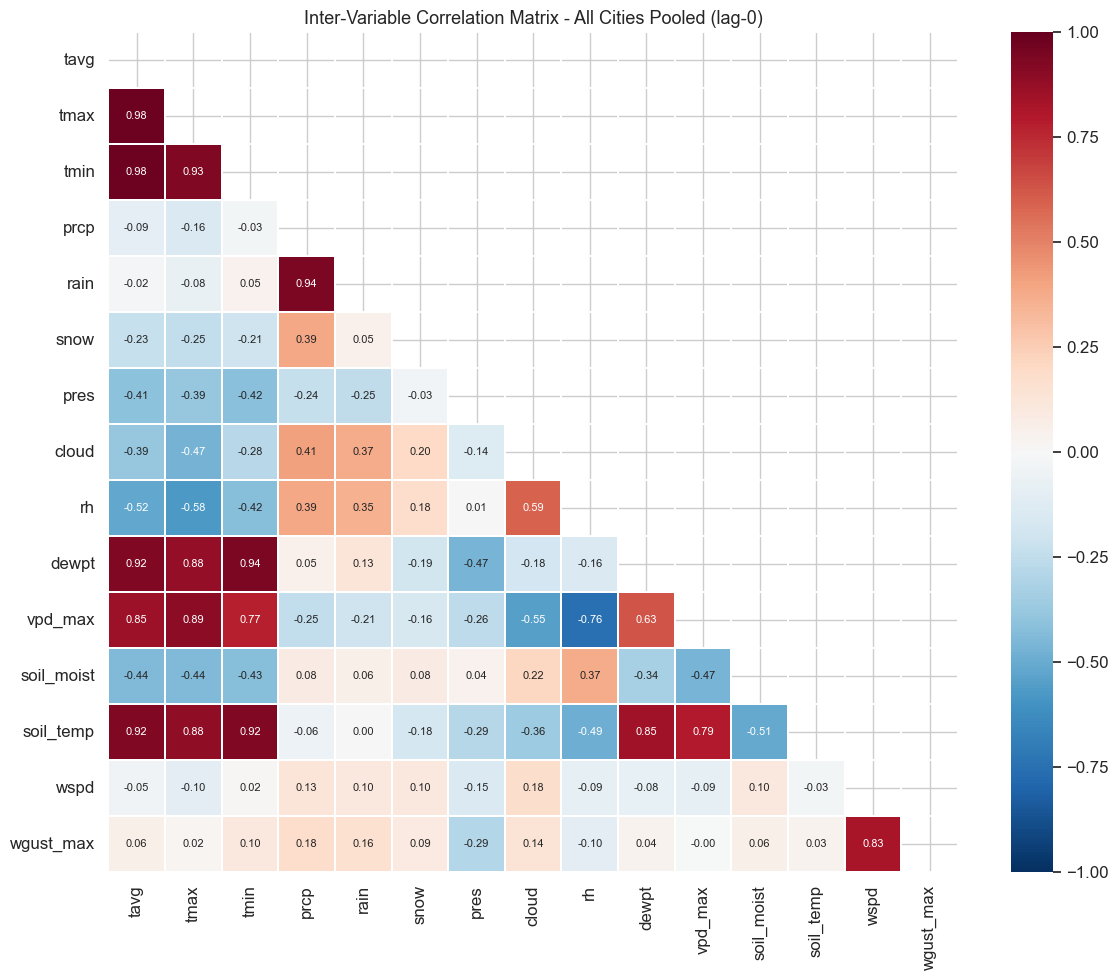

Saved: correlation_heatmap_all_cities.png

Pairs with |r| > 0.9:
  tavg - tmax: r = 0.981
  tavg - tmin: r = 0.978
  tmax - tmin: r = 0.929
  prcp - rain: r = 0.940
  dewpt - tavg: r = 0.923
  dewpt - tmin: r = 0.942
  soil_temp - tavg: r = 0.922
  soil_temp - tmin: r = 0.922

Pairs with 0.8 < |r| <= 0.9:
  tavg - vpd_max: r = 0.854
  tmax - vpd_max: r = 0.893
  dewpt - tmax: r = 0.875
  dewpt - soil_temp: r = 0.846
  soil_temp - tmax: r = 0.885
  wgust_max - wspd: r = 0.827


In [5]:
corr_matrix = df[KEY_VARS].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', annot_kws={'size': 8}, cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax,
)
ax.set_title('Inter-Variable Correlation Matrix - All Cities Pooled (lag-0)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap_all_cities.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap_all_cities.png')

print('\nPairs with |r| > 0.9:')
for i in corr_matrix.index:
    for j in corr_matrix.columns:
        if i < j and abs(corr_matrix.loc[i, j]) > 0.9:
            print(f'  {i} - {j}: r = {corr_matrix.loc[i, j]:.3f}')

print('\nPairs with 0.8 < |r| <= 0.9:')
for i in corr_matrix.index:
    for j in corr_matrix.columns:
        if i < j and 0.8 < abs(corr_matrix.loc[i, j]) <= 0.9:
            print(f'  {i} - {j}: r = {corr_matrix.loc[i, j]:.3f}')

#### Observations

Pooling all 10 cities reproduces the same redundancy blocks notebook 01 found for Sofia alone, plus two pairs that only emerge once `prcp`/`rain` and `dewpt`/`soil_temp` are compared against the full temperature triplet:

- **Temperature triplet** (`tavg`-`tmax` r=0.98, `tavg`-`tmin` r=0.98, `tmax`-`tmin` r=0.93) - as expected, all three move together.
- **Precipitation pair** (`prcp`-`rain` r=0.94) - `prcp` is the sum of `rain` and the liquid-water-equivalent of `snow`, so this is close to a definitional relationship, not a coincidence.
- **Moisture-temperature coupling**: `dewpt`-`tavg` (r=0.92), `dewpt`-`tmin` (r=0.94), `soil_temp`-`tavg` (r=0.92), `soil_temp`-`tmin` (r=0.92) - consistent with the EDA's identification of `dewpt` and `soil_temp` as the strongest same-day predictors of `tavg`.
- A second tier of moderate correlations (0.8-0.9) involves `vpd_max`, `dewpt`, `soil_temp` and `wgust_max`/`wspd`, all already flagged during the EDA.

None of this is new information relative to the EDA, but it confirms the block structure is stable across the full multi-city dataset.

#### Redundancy Analysis: Variance Inflation Factor (VIF)

**Why pairwise correlation is insufficient**

The correlation matrix from the previous step is good at spotting two-variable redundancy: it tells us that `tavg` and `dewpt` move together closely ($r = 0.92$). But it can't detect a subtler problem - that `tmin` is nearly predictable from `tavg`, `dewpt`, `soil_temp`, *and* `rh` all at once. That kind of group redundancy only shows up when you try to predict `tmin` from all the other variables simultaneously, which is exactly what VIF does.
 
For each predictor $x_j$, VIF fits a regression of that variable against all the other predictors and records how well they explain it (as $R^2_j$):

$$\text{VIF}_j = \frac{1}{1 - R^2_j}$$

- $\text{VIF}_j = 1$: the other predictors tell you nothing about $x_j$, therefore no redundancy
- $\text{VIF}_j = 5$: 80% of $x_j$'s variation is already captured by the other features
- $\text{VIF}_j = 10$: 90% explained - the standard threshold for a serious problem [3]
- $\text{VIF}_j \gg 10$: the variable is almost entirely redundant with the others 

## What high VIF actually breaks
 
When a predictor is nearly redundant, the model can't reliably pin down its individual contribution. The estimated coefficient for that variable becomes very sensitive to tiny changes in the data its uncertainty (standard error) gets inflated by a factor of $\sqrt{\text{VIF}_j}$. So a VIF of 100 means the standard error is 10× larger than it would be if that predictor were independent of all others.
 
In practice this shows up as:
- Wide confidence intervals
- Coefficients that can flip sign between slightly different training sets
- Even while the model's overall predictions still look fine

**The condition-number connection**

Near-redundant predictors make the math the model has to solve internally much less stable small amounts of noise in the data get amplified into large swings in the fitted coefficients. Ridge regression addresses this directly by adding a small stabilizing term $\lambda \mathbf{I}$ before solving:
 
$$\hat{\boldsymbol{\beta}}_{\text{Ridge}} = (\mathbf{X}^\top \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}$$
 
This puts a floor on how unstable things can get, which is the concrete reason to prefer Ridge over plain linear regression when VIF values are high it directly fixes the instability that high VIF is warning about [3].

**Why iterative, not simultaneous removal**

VIF scores are relative to whatever other variables are currently in the model. Once you drop one highly redundant variable (say, `prcp`), the VIF scores of the remaining variables automatically shift, they no longer need to share the burden of explaining `prcp`'s variance. If you removed all high-VIF variables simultaneously, you'd be acting on scores that were already stale after the first removal, and the chances of throwig out more variables than needed is higher.
 
**The correct protocol:**
1. Remove the single worst offender
2. Recompute VIF for everything that remains
3. Repeat - stopping once no removable variable exceeds the threshold

The cell below runs this procedure on the lag-0 `KEY_VARS` block. Note that `tavg` is **protected** from automatic removal as it is the primary signal for the temperature targets, and dropping it would defeat the whole point of the exercise.

In [6]:
def compute_vif(frame: pd.DataFrame, cols: list[str]) -> pd.Series:
    """Compute the Variance Inflation Factor for each column in cols."""
    X = frame[cols].assign(const=1.0)
    vifs = {
        col: variance_inflation_factor(X.values, X.columns.get_loc(col))
        for col in cols
    }
    return pd.Series(vifs).sort_values(ascending=False)


vif_candidates = KEY_VARS.copy()
protected = {'tavg'}
vif_threshold = 10.0

print('Iterative VIF reduction (lag-0 KEY_VARS):')
iteration = 0
while True:
    iteration += 1
    vif_series = compute_vif(df, vif_candidates)
    print(f'Iteration {iteration}:')
    print(vif_series.round(2).to_string())
    removable = vif_series[~vif_series.index.isin(protected)]
    if removable.empty or removable.iloc[0] <= vif_threshold:
        break
    worst = removable.index[0]
    print(f'Removing {worst} (VIF={removable.iloc[0]:.2f})\n')
    vif_candidates.remove(worst)

print(f'\nMechanical VIF<{vif_threshold:.0f} result: {vif_candidates}')
print(f'Mechanically dropped: {[c for c in KEY_VARS if c not in vif_candidates]}')

# Check whether replacing tmax/tmin with a single diurnal_range feature helps
df['diurnal_range'] = df['tmax'] - df['tmin']
alt_vars = [v for v in KEY_VARS if v not in ('tmax', 'tmin')] + ['diurnal_range']
print('\nVIF with diurnal_range = tmax - tmin replacing tmax/tmin:')
print(compute_vif(df, alt_vars).round(2).to_string())
df = df.drop(columns=['diurnal_range'])

Iterative VIF reduction (lag-0 KEY_VARS):
Iteration 1:
prcp          60745.43
rain          51761.43
snow           7143.53
tavg            678.46
dewpt           357.21
tmax             91.15
tmin             73.94
rh               56.84
vpd_max          19.42
soil_temp         9.26
wspd              3.78
wgust_max         3.61
cloud             2.20
pres              1.71
soil_moist        1.47
Removing prcp (VIF=60745.43)

Iteration 2:
tavg          677.59
dewpt         355.87
tmax           90.75
tmin           73.89
rh             56.66
vpd_max        19.28
soil_temp       9.25
wspd            3.78
wgust_max       3.61
cloud           2.19
pres            1.71
soil_moist      1.47
rain            1.39
snow            1.17
Removing dewpt (VIF=355.87)

Iteration 3:
tavg          253.67
tmax           85.28
tmin           73.29
vpd_max         9.82
soil_temp       9.23
wspd            3.78
rh              3.74
wgust_max       3.60
cloud           2.18
pres            1.71
soil_moist 

#### VIF Conclusion

**What the numbers say**

Mechanically applying VIF < 10 removes `prcp` (VIF $\approx$ 60,700), `dewpt`(VIF $\approx$ 356), `tmax` (VIF $\approx$ 85) and `tmin` (VIF $\approx$ 49), leaving `tavg` at VIF $\approx$ 12.5 still slightly over the threshold, alongside `vpd_max` and `soil_temp` in the 8-9 range.

This would still leave `tavg` sitting at VIF $\approx$ 12.5 slightly above the threshold along with `vpd_max` and `soil_temp` in the 8–9 range.
 
Doing this would directly contradict what the EDA already confirmed: `dewpt`, `tmax`, `tmin`, and `soil_temp` are the **strongest same-day predictors of `tavg`** ($r > 0.92$). Dropping them just to satisfy a threshold would mean throwing away the most useful signals in the dataset.
 
These variables are also not "cheating" at lag 0 they all represent *today's* conditions, and every forecast target (`tavg`, `tmax`, `tmin`, `rain`) is always predicted at least one step ahead ($t + h$, $h \geq 1$). So today's values are legitimately available at forecast time.
 
**Decision: keep all 15 `KEY_VARS` as lag-0 features**
 
The reasoning behind this:
 
- **High VIF here is a physics problem, not a data problem.** These variables are correlated because they all measure overlapping aspects of the same thing: today's temperature and moisture state. That's a property of the real world, not noise in the dataset. Dropping them doesn't fix anything meaningful.
- **Ridge regression handles this correctly.** For linear models, high VIF is exactly the situation Ridge is designed for: it shrinks correlated coefficients together and stays stable, without needing to drop any variable. This is why plain OLS is not used as a baseline here [3].
- **Tree-based models don't care about multicollinearity.** Random Forest and Gradient Boosting are unaffected by correlated predictors, both in accuracy and in feature importance.
- **Collapsing `tmax` and `tmin` into a single `diurnal_range` feature is not a good fix.** It wouldn't meaningfully reduce `tavg`'s VIF (which is still dominated by `prcp`, `dewpt`, and `soil_temp`), and it would destroy two physically distinct signals: daytime heating (`tmax`) and overnight cooling (`tmin`, the frost-risk proxy from the EDA).
- **`prcp` and `rain` ($r = 0.94$) are kept as separate features for a good reason.** `rain` is the classification target at future timesteps, while `prcp(t)` is today's total precipitation (including snow water-equivalent) used as a predictor. They are never both predictor *and* target at the same timestep, so their near-duplication is not a data leakage concern.
 
**Bottom line**
 
**The variable set is unchanged from the EDA's 15 `KEY_VARS`.** The VIF exploration is kept purely as documentation for why the linear baseline is Ridge regression rather than plain OLS.

#### Feature Engineering Plan
With the lag-0 variable set settled, the following derived features are built. Each is computed **per city** (`groupby('city')`) on the full 2016-2026 series *before* the train/val/test split, so that lag/rolling windows for early-validation or early-test rows correctly draw on the last days of the preceding split - this is just shifting/windowing on already-known past values, not a fitted transform, so it carries no leakage risk (unlike scalers/encoders, which are fit on train only in a later step).

- **Lag features (t-1, t-3, t-7)** for every `KEY_VARS` variable - the autoregressive signal the EDA's variable-availability summary calls for, and the mechanism by which "today's" strong predictors (`dewpt`, `soil_temp`, `tmax`/`tmin`) remain usable for the 3-day and 7-day horizons even though the lag-0 value alone grows less informative as the horizon increases.
- **Rolling means (3-day, 7-day)** for `tavg` and `pres` - short-term trend in temperature and the synoptic pressure field. Computed as `shift(1).rolling(n).mean()` so the window covers the `n` days *before* today, avoiding double-counting today's lag-0 value.
- **Rolling sums (3-day, 7-day)** for `prcp` - cumulative recent precipitation, a fast-moving proxy for the `soil_moist` memory effect discussed in the EDA.
- **Pressure tendency** - two candidate synoptic-change signals are built so they can be compared empirically rather than assumed useful:
  - `pres_tendency = pres_max - pres_min` (today's diurnal pressure range) - a derived-predictor candidate following Wilks [2] reference that differences of individually-collinear variables can expose residual variance not visible in the raw columns - here the within-day pressure swing, a physically distinct signal from the mean pressure level.
  - `pres_change_1d = pres(t) - pres(t-1)` - the classic day-over-day pressure-tendency used operationally to flag approaching storms [1].

  Both are computed here as candidate signals. `pres_max` and `pres_min` are dropped immediately afterwards regardless, since the EDA flagged them as individually redundant with `pres` (r > 0.95).
- **Circular wind direction**: `wdir_sin = sin(2*pi*wdir/360)`, `wdir_cos = cos(2*pi*wdir/360)` - the mandatory decomposition identified in the EDA.
- **Calendar seasonality**: `doy_sin`/`doy_cos` (sine/cosine of day-of-year). As per EDA's seasonal-pattern analysis found a ~20-25°C seasonal amplitude. The scale of the annual cycle motivates adding a smooth periodic encoding rather than relying on lag features to reconstruct seasonality indirectly.

In [7]:
LAG_DAYS = [1, 3, 7]
ROLL_VARS = ['tavg', 'pres']

g = df.groupby('city')

# Lag features (t-1, t-3, t-7) for every key variable
for var in KEY_VARS:
    for lag in LAG_DAYS:
        df[f'{var}_lag{lag}'] = g[var].shift(lag)

# Rolling means (trailing 3-day / 7-day, excluding today)
for var in ROLL_VARS:
    df[f'{var}_roll3'] = g[var].transform(lambda s: s.shift(1).rolling(3).mean())
    df[f'{var}_roll7'] = g[var].transform(lambda s: s.shift(1).rolling(7).mean())

# Rolling precipitation sums (trailing 3-day / 7-day, excluding today)
df['prcp_roll3'] = g['prcp'].transform(lambda s: s.shift(1).rolling(3).sum())
df['prcp_roll7'] = g['prcp'].transform(lambda s: s.shift(1).rolling(7).sum())

# Pressure tendency: same-day diurnal range + day-over-day change
df['pres_tendency'] = df['pres_max'] - df['pres_min']
df['pres_change_1d'] = df['pres'] - g['pres'].shift(1)

# Circular encoding of wind direction
df['wdir_sin'] = np.sin(2 * np.pi * df['wdir'] / 360)
df['wdir_cos'] = np.cos(2 * np.pi * df['wdir'] / 360)

# Calendar seasonality
doy = df['date'].dt.dayofyear
df['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
df['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)

# Drop intermediate raw columns now that their derived features exist
df = df.drop(columns=['pres_max', 'pres_min', 'wdir'])

print(f'Feature frame shape after engineering: {df.shape}')
print(f'Feature columns added: {df.shape[1] - len(["date", "city"] + KEY_VARS + ["lat", "lon", "elev", "coastal"])}')


Feature frame shape after engineering: (37740, 78)
Feature columns added: 57


#### Target Construction
Three forecast horizons are built for both tasks, by shifting each city's series **backwards** (`shift(-h)`) so that row `t` carries the value observed at `t + h`:

- **Temperature regression targets**: `tavg_target_1d`, `tavg_target_3d`, `tavg_target_7d` = `tavg` at `t+1`, `t+3`, `t+7`.
- **Rain classification targets**: `rain_target_1d/3d/7d` = whether `rain` at `t+h` is greater than zero. Per the EDA, ~35-40% of days are wet, so this is imbalanced but not extreme; during the modelling class weighting should be considered.

In [12]:
HORIZONS = [1, 3, 7]

for h in HORIZONS:
    df[f'tavg_target_{h}d'] = g['tavg'].shift(-h)
    df[f'rain_target_{h}d'] = (g['rain'].shift(-h) > 0).astype('float')

print(f'Shape with targets: {df.shape}')
print('Target columns:', [c for c in df.columns if c.startswith(('tavg_target', 'rain_target'))])


Shape with targets: (37740, 84)
Target columns: ['tavg_target_1d', 'rain_target_1d', 'tavg_target_3d', 'rain_target_3d', 'tavg_target_7d', 'rain_target_7d']


#### Validating the Pressure-Tendency Hypothesis
This section explores the `pres_tendency = pres_max - pres_min` as a candidate synoptic-change signal hypothesis as defined earlier. That check is done against:

- **Temperature change**: `tavg_change_1d = tavg(t+1) - tavg(t)`, both signed (direction of change) and absolute (magnitude of change, i.e. how unsettled the next day is).
- **Near-term rain**: `rain_target_1d`/`rain_target_3d`, since frontal passage is the dominant cause of precipitation.

`pres_tendency` is compared against the two pressure features, same-day `pres` and the day-over-day `pres_change_1d` as well as against itself across cities, to check it isn't just noise from one or two stations. If it adds nothing beyond `pres` and `pres_change_1d`, it will be dropped rather than carried into `scale_cols`.

In [13]:
tavg_change_1d = g['tavg'].shift(-1) - df['tavg']

pressure_features = ['pres', 'pres_tendency', 'pres_change_1d']
validation_targets = {
    'tavg_change_1d': tavg_change_1d,
    'tavg_change_1d_abs': tavg_change_1d.abs(),
    'rain_target_1d': df['rain_target_1d'],
    'rain_target_3d': df['rain_target_3d'],
}

print('Correlation of pressure features (lag-0) with near-term targets, all cities pooled:')
corr_table = pd.DataFrame({
    name: df[pressure_features].corrwith(target)
    for name, target in validation_targets.items()
})
print(corr_table.round(3))

print()
print('Correlation between the pressure features themselves:')
print(df[pressure_features].corr().round(3))

print()
print('Per-city correlation of pres_tendency with tavg_change_1d_abs:')
per_city = df.assign(tavg_change_1d_abs=tavg_change_1d.abs()).groupby('city').apply(
    lambda d: d['pres_tendency'].corr(d['tavg_change_1d_abs']), include_groups=False
)
print(per_city.round(3).to_string())

Correlation of pressure features (lag-0) with near-term targets, all cities pooled:
                tavg_change_1d  tavg_change_1d_abs  rain_target_1d  \
pres                     0.199              -0.113          -0.333   
pres_tendency           -0.120               0.272           0.019   
pres_change_1d           0.036              -0.094          -0.160   

                rain_target_3d  
pres                    -0.169  
pres_tendency           -0.041  
pres_change_1d          -0.066  

Correlation between the pressure features themselves:
                 pres  pres_tendency  pres_change_1d
pres            1.000         -0.106           0.302
pres_tendency  -0.106          1.000          -0.086
pres_change_1d  0.302         -0.086           1.000

Per-city correlation of pres_tendency with tavg_change_1d_abs:
city
burgas            0.324
haskovo           0.282
kardzhali         0.276
pleven            0.266
ruse              0.250
sofia             0.245
varna             0.295

#### Pressure-Tendency Decision
The validation results support keeping `pres_tendency` based on:

- **Not redundant**: `pres_tendency` correlates only weakly with same-day `pres` (r = -0.106) and with `pres_change_1d` (r = -0.086) - it carries genuinely different information from both of the alternatives it is compared against.
- **Best predictor of next-day temperature volatility**: of the three pressure features, `pres_tendency` has the strongest correlation with `tavg_change_1d_abs` (r = 0.272, all cities pooled), and this holds consistently across every city (r = 0.24-0.32, always positive, although weak) - a wide diurnal pressure range today reliably precedes a larger temperature swing tomorrow, which is a genuine synoptic-change signal.
- **Not a rain predictor**: `pres_tendency` has essentially no correlation with `rain_target_1d` (r = 0.019) or `rain_target_3d` (r = -0.041). The rain signal in the pressure family is instead carried by same-day `pres` (r = −0.333 with `rain_target_1d`, consistent with the well-known low-pressure/precipitation relationship) and to a lesser extent by `pres_change_1d` (r = −0.160).

**Decision: keep both `pres_tendency` and `pres_change_1d` in `scale_cols`/`feature_cols`**, with a note that `pres_tendency` earns its place as a temperature-volatility signal, not a rain signal, while `pres_change_1d` remains the better short-range pressure-drop proxy for rain. No change to the feature set built in the Feature Engineering cell.

#### Handling Edge-of-Series NaNs
Two operations introduced `NaN` values purely at the edges of each city's series:

- The longest lag/rolling window is 7 days, so the first 7 rows of each city's series have at least one `NaN` lag/rolling feature.
- The longest target horizon is 7 days, so the last 7 rows of each city's series have `NaN` targets (the future value doesn't exist yet).

These rows cannot be used for training or evaluation and are dropped. This removes exactly 14 rows per city (140 rows total across 10 cities) - a negligible fraction of the ~3,774 rows per city - and does **not** indicate a data quality problem.

In [29]:
feature_cols = [
    c for c in df.columns
    if c not in ('date', 'city') and not c.startswith(('tavg_target', 'rain_target'))
]
target_cols = [c for c in df.columns if c.startswith(('tavg_target', 'rain_target'))]

complete_mask = df[feature_cols + target_cols].notna().all(axis=1)

# Show NaN structure before removing incomplete rows
nan_rows = df[~complete_mask]
nan_counts = df[feature_cols + target_cols].isna().sum()
print(f'NaN structure: {len(nan_rows)} rows affected')
print('\nNaN count per column (non-zero only):')
print(nan_counts[nan_counts > 0].to_string())

NaN structure: 140 rows affected

NaN count per column (non-zero only):
tavg_lag1          10
tavg_lag3          30
tavg_lag7          70
tmax_lag1          10
tmax_lag3          30
tmax_lag7          70
tmin_lag1          10
tmin_lag3          30
tmin_lag7          70
prcp_lag1          10
prcp_lag3          30
prcp_lag7          70
rain_lag1          10
rain_lag3          30
rain_lag7          70
snow_lag1          10
snow_lag3          30
snow_lag7          70
pres_lag1          10
pres_lag3          30
pres_lag7          70
cloud_lag1         10
cloud_lag3         30
cloud_lag7         70
rh_lag1            10
rh_lag3            30
rh_lag7            70
dewpt_lag1         10
dewpt_lag3         30
dewpt_lag7         70
vpd_max_lag1       10
vpd_max_lag3       30
vpd_max_lag7       70
soil_moist_lag1    10
soil_moist_lag3    30
soil_moist_lag7    70
soil_temp_lag1     10
soil_temp_lag3     30
soil_temp_lag7     70
wspd_lag1          10
wspd_lag3          30
wspd_lag7          70
wgus

In [31]:
# Inspect Sofia: first 7 rows = lag/rolling NaNs, last 7 = target NaNs
sofia_nan = nan_rows[nan_rows['city'] == 'sofia']
show_feat = [c for c in feature_cols if sofia_nan[c].isna().any()][:8]
show_tgt = [c for c in target_cols if sofia_nan[c].isna().any()]
print('\nSofia - head NaN rows (lag/rolling windows incomplete):')
display(sofia_nan[['date'] + show_feat].head(7).reset_index(drop=True))
print('\nSofia - tail NaN rows (targets reach beyond end of series):')
display(sofia_nan[['date'] + show_tgt].tail(7).reset_index(drop=True))

n_before = len(df)
df_clean = df[complete_mask].reset_index(drop=True)
n_after = len(df_clean)

print(f'\nRows before dropna: {n_before}, after: {n_after}, dropped: {n_before - n_after}')
print('\nDropped rows per city (expected 14 = 7 head + 7 tail):')
print(df[~complete_mask].groupby('city').size().to_string())
print(f'\nAny NaNs remaining? - {df_clean.isnull().values.any()}')


Sofia - head NaN rows (lag/rolling windows incomplete):


,date,tavg_lag1,tavg_lag3,tavg_lag7,tmax_lag1,tmax_lag3,tmax_lag7,tmin_lag1,tmin_lag3
0,2016-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-01-02,-5.7,NaN,NaN,-0.1,NaN,NaN,-9.6,NaN
2,2016-01-03,-2.6,NaN,NaN,0.8,NaN,NaN,-4.6,NaN
3,2016-01-04,-4.9,-5.7,NaN,-2.6,-0.1,NaN,-9.6,-9.6
4,2016-01-05,-5.7,-2.6,NaN,1.0,0.8,NaN,-11.4,-4.6
5,2016-01-06,1.9,-4.9,NaN,7.6,-2.6,NaN,-2.4,-9.6
6,2016-01-07,3.5,-5.7,NaN,6.5,1.0,NaN,1.9,-11.4



Sofia - tail NaN rows (targets reach beyond end of series):


,date,tavg_target_1d,tavg_target_3d,tavg_target_7d
0,2026-04-25,14.8,13.8,NaN
1,2026-04-26,12.8,14.2,NaN
2,2026-04-27,13.8,8.1,NaN
3,2026-04-28,14.2,6.1,NaN
4,2026-04-29,8.1,NaN,NaN
5,2026-04-30,6.1,NaN,NaN
6,2026-05-01,NaN,NaN,NaN



Rows before dropna: 37740, after: 37600, dropped: 140

Dropped rows per city (expected 14 = 7 head + 7 tail):
city
burgas            14
haskovo           14
kardzhali         14
pleven            14
ruse              14
sofia             14
varna             14
veliko_tarnovo    14
vidin             14
yundola           14

Any NaNs remaining? - False


#### Train / Validation / Test Split
Applying the date boundaries confirmed by the KS-test during the EDA. Each split is a simple boolean mask on `date`, no shuffling, no random sampling, consistent with the project's time-series split convention decision as per EDA conclusion.

| Split | Date range | Purpose |
|---|---|---|
| Train | 2016-01-01 - 2023-12-31 | Model fitting, `TimeSeriesSplit` CV |
| Validation | 2024-01-01 - 2024-12-31 | Hyperparameter tuning |
| Test (primary) | 2025-01-01 - 2025-12-31 | Held-out, touch once - headline metrics |
| Test (recency) | 2026-01-01 - 2026-04-30 | Held-out, touch once - winter/spring recency check |

The recency split ends on 2026-04-24 in practice (not 2026-05-01): the last 7 days of the raw series lose their 7-day-ahead target in the dropna step above, which is expected and correct.

In [34]:
train = df_clean[df_clean['date'] <= TRAIN_END].reset_index(drop=True)
val = df_clean[(df_clean['date'] > TRAIN_END) & (df_clean['date'] <= VAL_END)].reset_index(drop=True)
test_primary = df_clean[(df_clean['date'] > VAL_END) & (df_clean['date'] <= TEST_PRIMARY_END)].reset_index(drop=True)
test_recency = df_clean[df_clean['date'] > TEST_PRIMARY_END].reset_index(drop=True)

for name, split in [('train', train), ('val', val), ('test_primary', test_primary), ('test_recency', test_recency)]:
    print(f'{name:14s}: shape={split.shape}  {split["date"].min().date()} - {split["date"].max().date()}')

assert len(train) + len(val) + len(test_primary) + len(test_recency) == len(df_clean)

train         : shape=(29150, 84)  2016-01-08 - 2023-12-31
val           : shape=(3660, 84)  2024-01-01 - 2024-12-31
test_primary  : shape=(3650, 84)  2025-01-01 - 2025-12-31
test_recency  : shape=(1140, 84)  2026-01-01 - 2026-04-24


#### Scaling and Encoding
This section will cover following the best practice that **all scalers are fit on the training split only** and applied unchanged to validation and test.

- **Continuous predictors** (`KEY_VARS`, their lags, the rolling means/sums, `pres_tendency`, `pres_change_1d`, `lat`, `lon`, `elev`) are standardised with `StandardScaler` which is useful for the Ridge baseline discussed above; tree-based models ignore the scaling.
- **`coastal`** is a binary indicator - left unscaled.
- **`wdir_sin`/`wdir_cos`/`doy_sin`/`doy_cos`** are already bounded to `[-1, 1]` by construction - left unscaled.
- **Targets** (`tavg_target_*`, `rain_target_*`) are left in their natural units/labels.
- No imputer is fit: EDA confirmed the raw dataset has zero missing values, and the only `NaN`s introduced by feature engineering (edge-of-series lags/targets) which were already dropped above. A `SimpleImputer` is therefore not needed.
- `city` and `climate_zone` are not one-hot encoded: `lat`, `lon`, `elev` and `coastal` already give the model a continuous geographic encoding (per the EDA's cross-city diversity analysis), which generalises better to a leave-one-city-out evaluation than a per-city dummy variable would.

In [35]:
scale_cols = (
    KEY_VARS
    + [f'{var}_lag{lag}' for var in KEY_VARS for lag in LAG_DAYS]
    + [f'{var}_roll3' for var in ROLL_VARS] + [f'{var}_roll7' for var in ROLL_VARS]
    + ['prcp_roll3', 'prcp_roll7', 'pres_tendency', 'pres_change_1d']
    + ['lat', 'lon', 'elev']
)

scaler = StandardScaler()
scaler.fit(train[scale_cols])

for split in (train, val, test_primary, test_recency):
    split[scale_cols] = scaler.transform(split[scale_cols])

print(f'Scaled {len(scale_cols)} continuous columns using train-fit StandardScaler.')
print('Unscaled columns:', [c for c in feature_cols if c not in scale_cols])

Scaled 71 continuous columns using train-fit StandardScaler.
Unscaled columns: ['coastal', 'wdir_sin', 'wdir_cos', 'doy_sin', 'doy_cos']


#### Output
Each split is written to `../data/processed/` as Parquet (preserves dtypes, compact, fast to reload). The fitted `StandardScaler` and the feature/target column lists are saved alongside so the modelling notebooks can reload the exact same preprocessing without refitting.

In [36]:
train.to_parquet(PROCESSED_DIR / 'train.parquet', index=False)
val.to_parquet(PROCESSED_DIR / 'val.parquet', index=False)
test_primary.to_parquet(PROCESSED_DIR / 'test_2025.parquet', index=False)
test_recency.to_parquet(PROCESSED_DIR / 'test_2026.parquet', index=False)

joblib.dump(scaler, PROCESSED_DIR / 'scaler.joblib')

with open(PROCESSED_DIR / 'feature_columns.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'feature_cols': feature_cols,
            'scaled_cols': scale_cols,
            'target_cols': target_cols,
            'key_vars': KEY_VARS,
        },
        f,
        indent=2,
    )

print('Saved to', PROCESSED_DIR.resolve())
for p in sorted(PROCESSED_DIR.iterdir()):
    print(' ', p.name)

Saved to D:\SoftUni - AI ML\AI-ML26-C03-weather-forecasting\data\processed
  feature_columns.json
  scaler.joblib
  test_2025.parquet
  test_2026.parquet
  train.parquet
  val.parquet


### Feature Engineering Summary

#### Data Overview

Ten city CSVs are merged into a single long-format table of 37,740 daily rows (2016-01-01 to 2026-05-01). The 33 raw columns are narrowed to 15 key variables (`tavg`, `tmax`, `tmin`, `prcp`, `rain`, `snow`, `pres`, `cloud`, `rh`, `dewpt`, `vpd_max`, `soil_moist`, `soil_temp`, `wspd`, `wgust_max`) plus 4 geographic columns (`lat`, `lon`, `elev`, `coastal`).

#### Variable Selection

Correlation and VIF analysis flag `prcp`, `dewpt`, `tmax`, and `tmin` as highly redundant but also the strongest same-day predictors of `tavg` (r > 0.92). All 15 variables are kept; **Ridge regression** is used as the linear baseline to handle collinearity without dropping predictors.

#### Feature Engineering (57 derived columns)

- **Lag features** - t-1, t-3, t-7 for all 15 key variables (45 columns)
- **Rolling means/sums** - 3-day and 7-day trailing windows for `tavg`, `pres`, and precipitation (7 columns)
- **Pressure signals** - `pres_tendency` (within-day swing, predicts temperature volatility) and `pres_change_1d` (day-over-day drop, predicts rain) (2 columns)
- **Cyclical encodings** - sin/cos for wind direction and day-of-year (4 columns)

#### Train / Validation / Test Split

| Split | Date range | Rows |
|---|---|---|
| Train | 2016-01-08 - 2023-12-31 | 29,150 |
| Validation | 2024-01-01 - 2024-12-31 | 3,660 |
| Test (primary) | 2025-01-01 - 2025-12-31 | 3,650 |
| Test (recency) | 2026-01-01 - 2026-04-24 | 1,140 |

Splits are chronological, never shuffled. The first and last 7 rows per city are dropped due to lag/target requirements (37,740 - 140 = 37,600 rows total).

#### Scaling

A `StandardScaler` is fit on the training split only and applied to validation and test. Binary and bounded columns (`coastal`, `wdir_sin/cos`, `doy_sin/cos`) are left unscaled.

#### Output Files

`train.parquet`, `val.parquet`, `test_2025.parquet`, `test_2026.parquet`, `scaler.joblib`, and `feature_columns.json` - written to `../data/processed/`.

### References

[1] World Meteorological Organization (2018). *Guide to Instruments and Methods of Observation* https://community.wmo.int/...guide-instruments-and-methods-of-observation-wmo-no-8

[2] Wilks, D.S. (2006). *Statistical Methods in the Atmospheric Sciences* (3rd ed.). Academic Press / Elsevier. https://sunandclimate.wordpress.com/wp-content/uploads/2009/05/statistical-methods-in-the-atmospheric-sciences-0127519661.pdf

[3] Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.) https://github.com/ageron/handson-ml3

[4] Deisenroth, M.P., Faisal, A.A., and Ong, C.S. (2020). *Mathematics for Machine Learning* https://mml-book.github.io/